# 08 · Pseudo real-time evaluation, 2012–2025

A nowcasting model earns its keep out of sample. The standard design (Giannone,
Reichlin & Small, 2008; Bańbura et al., 2013) re-creates, for every date in an
evaluation window, the data set a forecaster would have seen — each series cut at its
publication lag — re-estimates the model, and records the backcast, nowcast and
forecast of GDP. Accuracy is then reported **by horizon** (how far the vintage is from
the end of the target quarter) and compared with simple benchmarks using forecast
comparison tests.

Design of this notebook:

* **data**: the compact Brazilian panel (GDP + 21 monthly indicators), monthly
  vintages on the 15th of each month from January 2012 to December 2025, cut with the
  actual GDP release dates and typical delays of the indicators (pseudo real time:
  today's data, historical availability);
* **model**: mixed-frequency DFM estimated by EM (one global factor), parameters
  re-estimated every quarter (`refit_every=3`), the Kalman filter updating the
  nowcast with each month's data in between;
* **benchmarks**: AR(1), random walk, a bridge equation on IBC-Br, industrial
  production and retail, U-MIDAS (Foroni, Marcellino & Schumacher, 2015) and
  exponential-Almon MIDAS (Ghysels, Santa-Clara & Valkanov, 2004) on IBC-Br, and a
  ridge regression from scikit-learn (any scikit-learn regressor can be a benchmark:
  innovation I11);
* **realisations**: the *published* GDP growth (the model is estimated on a panel
  whose extreme observations were winsorised, but it is scored against the actual
  data, including 2020).

In [1]:
import sys
import time
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from utils import OUTPUTS_DIR, brazil_panel, display, md, setup, show

import nowcastbox as nb

setup(blas_threads=1)  # the backtest runs in parallel processes

In [2]:
ds, panel = brazil_panel(start="2005-01")
published = nb.apply_transforms(ds.data, ds.transform).to_native("pib")
calendar = nb.load_brazil_calendar()

benchmarks = {
    "AR": nb.benchmarks.AR(p=1),
    "RW": nb.benchmarks.RandomWalk(),
    "Bridge": nb.benchmarks.BridgeBenchmark(predictors=["ibc_br", "pim_geral", "pmc_varejo"]),
    "U-MIDAS": nb.benchmarks.UMIDAS(predictors=["ibc_br", "pim_geral"]),
    "MIDAS": nb.benchmarks.MIDAS(predictors=["ibc_br"], polynomial="exp_almon"),
    "Ridge": nb.benchmarks.SklearnBenchmark(RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0])),
}
backtest = nb.PseudoRealTimeBacktest(
    model=nb.MixedFreqDFM(n_factors=1, factor_lags=1, max_iter=50),
    data=panel,
    target="pib",
    calendar=calendar,
    start="2012-01-15",
    end="2025-12-15",
    step="M",
    benchmarks=benchmarks,
    refit_every=3,
    actual=published,
    n_jobs=4,
)
start = time.perf_counter()
out = backtest.run()
md(f"Backtest: **{time.perf_counter() - start:.0f} s** for 168 vintages and 7 models.")
print(out.summary())

Backtest: **22 s** for 168 vintages and 7 models.

Pseudo real-time backtest
Target: pib    Models: MixedFreqDFM, AR, RW, Bridge, U-MIDAS, MIDAS, Ridge
Vintages: 168 (2012-01-15 to 2025-12-15)    Target periods: 58

Accuracy (common sample, all horizons)
metric        rmsfe    mae    bias        n  rel_rmsfe
model                                                 
MixedFreqDFM 0.0178 0.0096 -0.0022 448.0000     0.9154
AR           0.0194 0.0105 -0.0027 448.0000     1.0000
RW           0.0222 0.0131 -0.0003 448.0000     1.1416
Bridge       0.0188 0.0101 -0.0030 448.0000     0.9685
U-MIDAS      0.0189 0.0104 -0.0023 448.0000     0.9756
MIDAS        0.0188 0.0097 -0.0033 448.0000     0.9704
Ridge        0.0186 0.0104 -0.0022 448.0000     0.9579

RMSFE by months_to_end
               MixedFreqDFM     AR     RW  Bridge  U-MIDAS  MIDAS  Ridge
months_to_end                                                           
-2                   0.0149 0.0190 0.0200  0.0193   0.0207 0.0197 0.0171
-1                   0.0148 0.0190 0.0200  0.0166   0.0178

## 1. Accuracy by horizon

`months_to_end` is the number of months between the vintage and the end of the target
quarter: 5–3 are forecasts of next quarter, 2–0 nowcasts within the quarter, −1 and
−2 backcasts of a finished quarter whose GDP is not yet published.

,MixedFreqDFM,AR,RW,Bridge,U-MIDAS,MIDAS,Ridge
months_to_end,,,,,,,
-2,0.785,1.0,1.055,1.019,1.092,1.040,0.900
-1,0.782,1.0,1.055,0.877,0.939,0.969,0.919
0,0.873,1.0,1.052,0.916,0.980,1.008,0.959
1,0.918,1.0,1.222,0.966,0.872,0.851,0.887
2,0.947,1.0,1.222,0.978,0.915,0.896,0.956
3,0.980,1.0,1.235,0.978,0.943,0.917,0.989
4,0.994,1.0,1.124,1.000,1.011,1.045,1.026
5,1.000,1.0,1.124,1.002,1.050,1.035,1.018


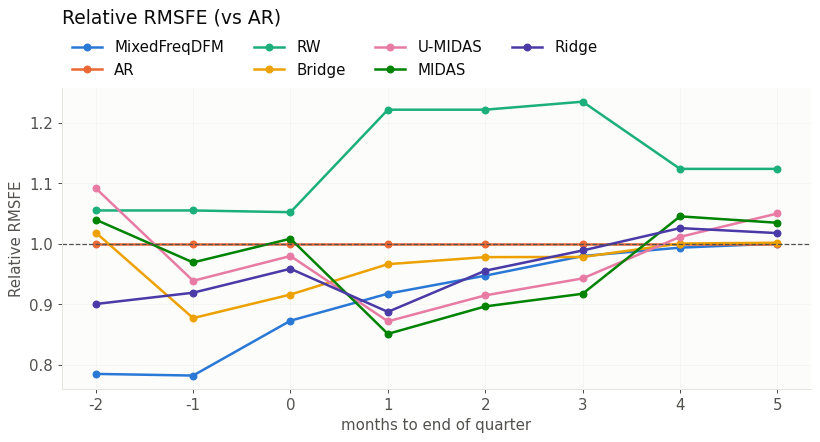

In [3]:
relative = out.relative_to("AR")
display(relative.round(3))
fig = nb.visualization.plot_rmsfe_by_horizon(
    out.rmsfe_by_horizon(),
    relative_to="AR",
    backend="matplotlib",
    xlabel="months to end of quarter",
)
show(fig, "08_relative_rmsfe")

Over the full window the DFM has the lowest RMSFE at the end of the quarter and for
the backcasts (gains of 13–22 % over the AR(1)); early in the quarter
(`months_to_end` = 1–2) the single-equation MIDAS models are slightly better; for
forecasts of next quarter (`months_to_end` ≥ 3–4) hardly anything beats the AR:
before the quarter starts there is little information on it. But the full window
includes 2020, whose two extreme quarters (−8.9 % and +7.9 %) dominate any
squared-error statistic.

## 2. Without the pandemic

`BacktestResults.to_frame()` holds every forecast, so any sub-sample is a `groupby`
away. Excluding 2020Q1–2021Q1:

In [4]:
frame = out.evaluable()
pandemic = pd.period_range("2020Q1", "2021Q1", freq="Q")
calm = frame[~frame["target_period"].isin(pandemic)]
rmsfe_calm = (
    calm.groupby(["months_to_end", "model"])["error"]  # noqa: PD010
    .apply(lambda e: float(np.sqrt(np.mean(np.square(e)))))
    .unstack()
)
display((rmsfe_calm.div(rmsfe_calm["AR"], axis=0)).round(3))

model,AR,Bridge,MIDAS,MixedFreqDFM,RW,Ridge,U-MIDAS
months_to_end,,,,,,,
-2,1.0,0.803,0.542,0.738,1.164,1.071,0.838
-1,1.0,0.912,0.654,0.793,1.164,1.109,0.689
0,1.0,0.938,0.859,0.857,1.152,1.050,0.778
1,1.0,0.990,0.993,1.006,1.288,1.010,1.029
2,1.0,1.012,0.967,0.968,1.288,1.078,1.042
3,1.0,1.014,1.085,1.002,1.355,0.911,1.101
4,1.0,1.008,1.208,0.985,1.315,0.936,1.138
5,1.0,1.012,1.183,1.005,1.315,0.962,1.246


In normal times the picture changes. Once the quarter's IBC-Br is published
(backcasts, `months_to_end` < 0) the single-indicator **MIDAS on IBC-Br is the best
model**, with RMSFE 35–46 % below the AR — unsurprising, since the BCB builds IBC-Br
precisely as a monthly proxy of GDP. The DFM and U-MIDAS follow with gains of 14–26 %
within and right after the quarter; the bridge equation gains less and the ridge
regression on all indicators does not beat the AR. The DFM's advantage over the full
sample therefore comes from **robustness** rather than from normal-times precision:
it is never far from the best at any horizon.

## 3. Are the differences significant?

**Diebold-Mariano** with the Harvey-Leybourne-Newbold small-sample correction (squared
loss, reference AR), by horizon:

In [5]:
dm = out.diebold_mariano(reference="AR")
table = dm["statistic"].unstack("horizon").round(2)  # noqa: PD010
stars = dm["pvalue"].unstack("horizon").map(lambda p: "**" if p < 0.05 else "*" if p < 0.1 else "")  # noqa: PD010
display(table.astype(str) + stars)

horizon,-2,-1,0,1,2,3,4,5
model,,,,,,,,
Bridge,0.08,-0.76,-0.67,-1.29,-1.2,-1.18,0.08,0.4
MIDAS,0.12,-0.11,0.03,-1.3,-1.31,-1.04,2.17**,1.48
MixedFreqDFM,-1.52,-1.6,-1.3,-1.64,-1.66,-0.75,-0.92,0.07
RW,0.55,0.55,0.52,2.1**,2.1**,2.2**,1.46,1.46
Ridge,-1.24,-1.13,-1.01,-1.09,-0.81,-0.58,0.75,0.77
U-MIDAS,0.32,-0.23,-0.08,-1.21,-1.14,-0.72,0.36,1.94*


Negative statistics favour the model over the AR (`*` 10 %, `**` 5 %). With ~55
target quarters per horizon and the pandemic in the sample, the tests have low power.
The **Model Confidence Set** (Hansen, Lunde & Nason, 2011) asks a different question:
which models cannot be distinguished from the best one? (Pooled by forecast type.)

In [6]:
mcs = out.mcs(alpha=0.1, horizon="kind", n_bootstrap=500, random_state=0)
display(pd.concat({k: v.to_frame()[["included", "pvalue"]] for k, v in mcs.items()}, axis=1))

backcast        forecast         nowcast       
             included pvalue included pvalue included pvalue
MixedFreqDFM     True  1.000     True  1.000     True  1.000
Ridge            True  0.792     True  0.976     True  0.924
MIDAS            True  0.792     True  0.990     True  0.924
Bridge           True  0.792     True  0.990     True  0.458
AR               True  0.792     True  0.990     True  0.458
U-MIDAS          True  0.792     True  0.990     True  0.924
RW               True  0.698     True  0.266     True  0.190

At the 10 % level **no model is excluded** for any forecast type: with ~55 quarters
and the pandemic in the sample, the data cannot statistically separate the models,
although the DFM ranks first (MCS p-value 1) and the random walk last. This is the
typical outcome of nowcasting horse races on short samples, and a reason to report
accuracy by horizon and sub-sample rather than a single winner. The **Giacomini-White**
test of conditional predictive ability is also available
(`out.giacomini_white(reference="AR")`).

## 4. The nowcast errors over time

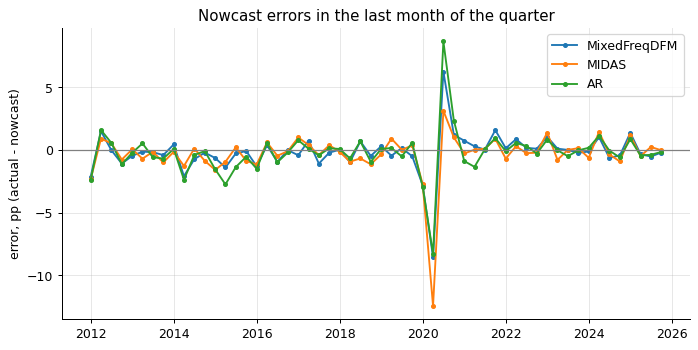

In [7]:
now = frame[frame["months_to_end"] == 0].pivot_table(
    index="target_period", columns="model", values="error"
)
fig, ax = plt.subplots()
for name in ("MixedFreqDFM", "MIDAS", "AR"):
    ax.plot(now.index.to_timestamp(), 100 * now[name], marker=".", label=name)
ax.axhline(0, color="grey", lw=1)
ax.set_ylabel("error, pp (actual - nowcast)")
ax.set_title("Nowcast errors in the last month of the quarter")
ax.legend()
show(fig, "08_errors")

Outside the pandemic the mean absolute nowcast error is about 0.6 pp for every
mixed-frequency model. In 2020Q2 **every** model missed the collapse by 7–12 pp. For
the DFM this is partly self-inflicted: `prepare_panel` replaced the April–May 2020
observations of the indicators by moving medians, so the model never saw the fall.
Pre-cleaning the panel is a reasonable choice for *estimation* in normal times and a
poor one for *nowcasting* during an extreme episode; notebook 10 compares it with
robust estimation that keeps the data.

## 5. Export (innovation I11)

The forecasts are a tidy table, exportable to Parquet for further analysis in pandas,
R or a BI tool.

In [8]:
OUTPUTS_DIR.mkdir(exist_ok=True)
path = OUTPUTS_DIR / "08_backtest_brazil.parquet"
out.to_parquet(path)
md(f"Wrote `{path.relative_to(OUTPUTS_DIR.parent)}` ({len(out.to_frame())} forecasts).")

Wrote `outputs/08_backtest_brazil.parquet` (3136 forecasts).

### References

* Bańbura, M., Giannone, D., Modugno, M. & Reichlin, L. (2013). Now-casting and the
  real-time data flow. *Handbook of Economic Forecasting*, vol. 2A, 195–237.
* Diebold, F. X. & Mariano, R. S. (1995). *JBES*, 13(3), 253–263; Harvey, D.,
  Leybourne, S. & Newbold, P. (1997). *IJF*, 13(2), 281–291.
* Foroni, C., Marcellino, M. & Schumacher, C. (2015). Unrestricted mixed data
  sampling (MIDAS). *JRSS A*, 178(1), 57–82.
* Ghysels, E., Santa-Clara, P. & Valkanov, R. (2004). The MIDAS touch: mixed data
  sampling regression models. Working paper.
* Giacomini, R. & White, H. (2006). Tests of conditional predictive ability.
  *Econometrica*, 74(6), 1545–1578.
* Hansen, P. R., Lunde, A. & Nason, J. M. (2011). The model confidence set.
  *Econometrica*, 79(2), 453–497.